# 05. BL Q 추정 방식 비교

동일한 BL Baseline 구조에서 **Q(뷰 수익률) 추정 방식만 다르게** 설정하여 성과를 비교한다.

## 비교 대상
| 방식 | 설명 |
|------|------|
| **Q_FIXED** | 문헌 기반 고정값 0.3%/월 (Ang et al. 2006, Baker et al. 2011) |
| **Q_hist** | 학습 기간 P 포트폴리오 평균 실현수익률 |
| **Q_ff3** | FF3 회귀로 추정한 P 포트폴리오 기대수익률 |

## 벤치마크
- **CAPM 균형**: BL 없이 μ=π 그대로 최적화
- **S&P 500 (SPY)**: 시장 지수

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import io, re, zipfile, requests
import warnings
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '05_BL_Q_Comparison'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 파라미터 ────────────────────────────────────────────────
TRAIN_WINDOW = 60
TAU          = 0.1
PCT_GROUP    = 0.30
START_PRED   = '2009-01-01'
Q_FIXED      = 0.003  # 월 0.3% = 연 3.6%

# ── 데이터 로드 ──────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[all_dates >= START_PRED]

print(f'패널: {panel.shape}')
print(f'예측 기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'Q_FIXED = {Q_FIXED}  (월 {Q_FIXED*100:.1f}%  |  연 {Q_FIXED*12*100:.1f}%)')

패널: (108135, 11)
예측 기간: 2009-01-31 ~ 2025-12-31 (204개월)
Q_FIXED = 0.003  (월 0.3%  |  연 3.6%)


In [2]:
# ── FF3 팩터 로드 ─────────────────────────────────────────────
FF3_PATH = DATA_DIR / 'ff3_monthly.csv'

def download_ff3():
    url = ('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'
           'F-F_Research_Data_Factors_CSV.zip')
    resp = requests.get(url, timeout=60)
    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        raw = zf.read(zf.namelist()[0]).decode('utf-8', errors='ignore')
    lines = raw.splitlines()
    start = next(i for i, l in enumerate(lines) if re.match(r'^\s*\d{6}\s*,', l))
    end   = next((i for i in range(start, len(lines))
                  if not re.match(r'^\s*\d{6}\s*,', lines[i])), len(lines))
    df = pd.read_csv(io.StringIO('\n'.join(lines[start-1:end])))
    df.columns = [c.strip() for c in df.columns]
    date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
    df = df.rename(columns={date_col: 'date', 'Mkt-RF': 'mkt_rf',
                             'SMB': 'smb', 'HML': 'hml', 'RF': 'rf'})
    return df.set_index('date').astype(float) / 100.0

if FF3_PATH.exists():
    ff3 = pd.read_csv(FF3_PATH, index_col='date', parse_dates=True)
    print(f'FF3 로드: {ff3.shape}')
else:
    print('FF3 다운로드 중...')
    ff3 = download_ff3()
    ff3.to_csv(FF3_PATH)
    print(f'FF3 저장: {ff3.shape}')

print(ff3.tail(3))

FF3 로드: (1196, 4)
            mkt_rf     smb     hml      rf
date                                      
2025-12-31 -0.0036 -0.0106  0.0242  0.0034
2026-01-31  0.0102  0.0220  0.0372  0.0030
2026-02-28 -0.0117  0.0014  0.0283  0.0028


In [3]:
# ── BL 구성 함수 ──────────────────────────────────────────────

def compute_sigma(ret_matrix):
    lw = LedoitWolf().fit(ret_matrix.values)
    return pd.DataFrame(lw.covariance_,
                        index=ret_matrix.columns,
                        columns=ret_matrix.columns)


def compute_pi(Sigma, w_mkt, spy_excess_ret, sigma2_mkt):
    lam = spy_excess_ret / sigma2_mkt if sigma2_mkt > 0 else 2.5
    lam = np.clip(lam, 0.5, 10.0)
    return lam * Sigma @ w_mkt, lam


def build_P(vol_series, mcap_series, pct=0.30):
    n_group    = max(1, int(len(vol_series) * pct))
    sorted_idx = vol_series.sort_values().index
    low_risk   = sorted_idx[:n_group]
    high_risk  = sorted_idx[-n_group:]
    P = pd.Series(0.0, index=vol_series.index)
    low_m  = mcap_series[low_risk]
    high_m = mcap_series[high_risk]
    P[low_risk]  =  low_m  / low_m.sum()
    P[high_risk] = -high_m / high_m.sum()
    return P


def compute_Q_hist(P, ret_matrix):
    """Q = 학습 기간 P 포트폴리오 평균 실현수익률"""
    p_vec = P.reindex(ret_matrix.columns).fillna(0).values
    return float((ret_matrix.values @ p_vec).mean())


def compute_Q_ff3(P, ret_matrix, ff3_train, rf_train):
    """Q = FF3 회귀로 추정한 P 포트폴리오 기대수익률"""
    view_tickers = [t for t in P[P != 0].index if t in ret_matrix.columns]
    if not view_tickers:
        return 0.0
    ff3_aligned = ff3_train.reindex(ret_matrix.index).dropna()
    rf_aligned  = rf_train.reindex(ff3_aligned.index).fillna(0)
    n = len(ff3_aligned)
    if n < 24:
        return 0.0
    X      = np.column_stack([np.ones(n), ff3_aligned[['mkt_rf', 'smb', 'hml']].values])
    X_next = np.array([1.0] + ff3_aligned[['mkt_rf', 'smb', 'hml']].tail(12).mean().tolist())
    rf_next = float(rf_train.iloc[-1]) if len(rf_train) > 0 else 0.0
    Y    = (ret_matrix[view_tickers].reindex(ff3_aligned.index).fillna(0).values
            - rf_aligned.values.reshape(-1, 1))
    coef = np.linalg.lstsq(X, Y, rcond=None)[0]
    r_hat_view = X_next @ coef + rf_next
    r_hat = pd.Series(0.0, index=ret_matrix.columns)
    for j, t in enumerate(view_tickers):
        r_hat[t] = r_hat_view[j]
    return float(P.reindex(ret_matrix.columns).fillna(0) @ r_hat)


def compute_omega(P, Sigma, tau):
    p = P.values
    return max(float(tau * p @ Sigma.values @ p), 1e-8)


def black_litterman(pi, Sigma, P, q, omega, tau):
    p    = P.values
    pi_v = pi.values
    tSig = tau * Sigma.values
    M      = float(p @ tSig @ p) + omega
    diff   = q - float(p @ pi_v)
    adjust = tSig @ p * (diff / M)
    return pd.Series(pi_v + adjust, index=pi.index)


def optimize_portfolio(mu, Sigma, lam):
    n   = len(mu)
    mu_ = mu.values
    Sig = Sigma.values
    def obj(w): return 0.5 * lam * w @ Sig @ w - w @ mu_
    def jac(w): return lam * Sig @ w - mu_
    res = minimize(obj, np.ones(n)/n, jac=jac, method='SLSQP',
                   bounds=[(0, 1)]*n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum()-1}])
    w = res.x if res.success else np.ones(n)/n
    return pd.Series(w, index=mu.index)


print('BL 함수 정의 완료')

BL 함수 정의 완료


In [ ]:
# ── Walk-forward: Q 방식별 결과 수집 ──────────────────────────
ret_pivot  = panel['ret_1m'].unstack('ticker')
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()

# 결과 저장소: q_method → 월별 수익률 리스트
results = {
    'Q_FIXED': [],
    'Q_hist':  [],
    'Q_ff3':   [],
    'CAPM':    [],
    'SPY':     [],
}
q_log = []  # 매월 Q 값 기록 (Q 수준 비교용)

print(f'Walk-forward: {pred_dates[0].date()} ~ {pred_dates[-1].date()}')

for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')

    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < 30:
            continue
        universe = month_df.index.tolist()

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]

        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=universe)
                              .dropna(axis=1, thresh=thresh)
                              .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue

        month_df = month_df.reindex(valid_tix)
        Sigma    = compute_sigma(ret_slice)

        mcap  = np.exp(month_df['log_mcap'])
        w_mkt = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)

        spy_s      = spy_series.reindex(train_dates)
        rf_s       = rf_series.reindex(train_dates)
        spy_excess = (spy_s - rf_s).mean()
        sigma2_mkt = spy_s.var()

        pi, lam = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)

        P = build_P(month_df['vol_21d'], mcap, pct=PCT_GROUP)
        P = P.reindex(valid_tix).fillna(0)
        omega = compute_omega(P, Sigma, TAU)

        # ── Q 방식별 계산 ────────────────────────────────────
        q_fixed = Q_FIXED
        q_hist  = compute_Q_hist(P, ret_slice)
        q_ff3   = compute_Q_ff3(P, ret_slice, ff3.reindex(train_dates), rf_s)

        q_log.append({'date': pred_date,
                      'Q_FIXED': q_fixed,
                      'Q_hist':  q_hist,
                      'Q_ff3':   q_ff3})

        # ── Q별 BL → 포트폴리오 가중치 ──────────────────────
        actual_ret = month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0)
        next_date  = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        r_spy      = float(spy_series.get(next_date, np.nan)) if next_date else np.nan

        for q_name, q_val in [('Q_FIXED', q_fixed), ('Q_hist', q_hist), ('Q_ff3', q_ff3)]:
            mu_BL = black_litterman(pi, Sigma, P, q_val, omega, TAU)
            w_bl  = optimize_portfolio(mu_BL, Sigma, lam)
            results[q_name].append({'date': pred_date, 'ret': float(w_bl @ actual_ret)})

        w_capm = optimize_portfolio(pi, Sigma, lam)
        results['CAPM'].append({'date': pred_date, 'ret': float(w_capm @ actual_ret)})
        results['SPY'].append({'date': pred_date, 'ret': r_spy})

    except Exception as e:
        if len(results['Q_FIXED']) <= 3:
            print(f'  [에러] {pred_date.date()}: {e}')

# DataFrame 변환
ret_series = {k: pd.DataFrame(v).set_index('date')['ret']
              for k, v in results.items()}
q_df = pd.DataFrame(q_log).set_index('date')

print(f'\n완료: {len(ret_series["Q_FIXED"])}개월')

Walk-forward: 2009-01-31 ~ 2025-12-31
  2009-12-31 (12/204)
  2010-12-31 (24/204)
  2011-12-31 (36/204)
  2012-12-31 (48/204)
  2013-12-31 (60/204)


=== 월별 Q 값 기술통계 ===
       Q_FIXED    Q_hist     Q_ff3
count  204.000  204.0000  204.0000
mean     0.003   -0.0018   -0.0019
std      0.000    0.0060    0.0131
min      0.003   -0.0206   -0.0407
25%      0.003   -0.0043   -0.0083
50%      0.003   -0.0011   -0.0025
75%      0.003    0.0018    0.0038
max      0.003    0.0169    0.0540


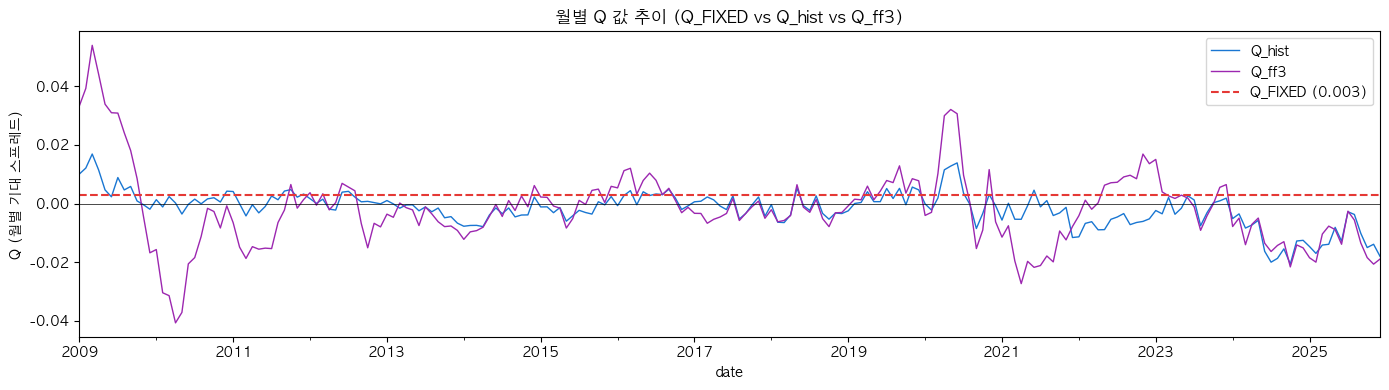

In [ ]:
# ── Q 수준 비교 ───────────────────────────────────────────────
print('=== 월별 Q 값 기술통계 ===')
print(q_df.describe().round(4))

fig, ax = plt.subplots(figsize=(14, 4))
q_df['Q_hist'].plot(ax=ax, label='Q_hist', color='#1976D2', linewidth=1.0)
q_df['Q_ff3'].plot(ax=ax,  label='Q_ff3',  color='#9C27B0', linewidth=1.0)
ax.axhline(Q_FIXED, color='#E53935', linestyle='--', linewidth=1.5,
           label=f'Q_FIXED ({Q_FIXED:.3f})')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('월별 Q 값 추이 (Q_FIXED vs Q_hist vs Q_ff3)')
ax.set_ylabel('Q (월별 기대 스프레드)')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'q_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 성과 분석 ────────────────────────────────────────────────
ANN = np.sqrt(12)
rf_monthly = panel['rf_1m'].groupby(level='date').first()

def performance(ret, label):
    rf      = rf_monthly.reindex(ret.index).fillna(0)
    excess  = ret - rf
    ann_ret = ret.mean() * 12
    ann_vol = ret.std() * ANN
    sharpe  = excess.mean() / excess.std() * ANN
    cum     = (1 + ret).cumprod()
    mdd     = ((cum - cum.cummax()) / cum.cummax()).min()
    cum_ret = cum.iloc[-1] - 1
    return {
        'label':    label,
        'ann_ret':  ann_ret,
        'ann_vol':  ann_vol,
        'sharpe':   sharpe,
        'cum_ret':  cum_ret,
        'mdd':      mdd,
    }

stats = [performance(ret_series[k], k)
         for k in ['Q_FIXED', 'Q_hist', 'Q_ff3', 'CAPM', 'SPY']]

stats_df = pd.DataFrame(stats).set_index('label')
stats_df[['ann_ret', 'ann_vol', 'sharpe', 'cum_ret', 'mdd']] = \
    stats_df[['ann_ret', 'ann_vol', 'sharpe', 'cum_ret', 'mdd']].round(4)

print('=== 포트폴리오 성과 비교 ===')
display_df = stats_df.copy()
display_df['ann_ret'] = display_df['ann_ret'].map('{:.2%}'.format)
display_df['ann_vol'] = display_df['ann_vol'].map('{:.2%}'.format)
display_df['sharpe']  = display_df['sharpe'].map('{:.3f}'.format)
display_df['cum_ret'] = display_df['cum_ret'].map('{:.2%}'.format)
display_df['mdd']     = display_df['mdd'].map('{:.2%}'.format)
display_df.columns   = ['연환산수익률', '연환산변동성', 'Sharpe', '누적수익률', 'MDD']
print(display_df.to_string())

=== 포트폴리오 성과 비교 ===
         연환산수익률  연환산변동성 Sharpe     누적수익률      MDD
label                                            
Q_FIXED  14.96%  11.90%  1.144  1011.62%  -13.70%
Q_hist   15.92%  15.22%  0.962  1110.98%  -21.57%
Q_ff3    17.79%  23.65%  0.698  1214.93%  -51.48%
CAPM     17.02%  15.96%  0.985  1330.11%  -22.17%
SPY      15.46%  14.72%  0.965      nan%  -23.93%


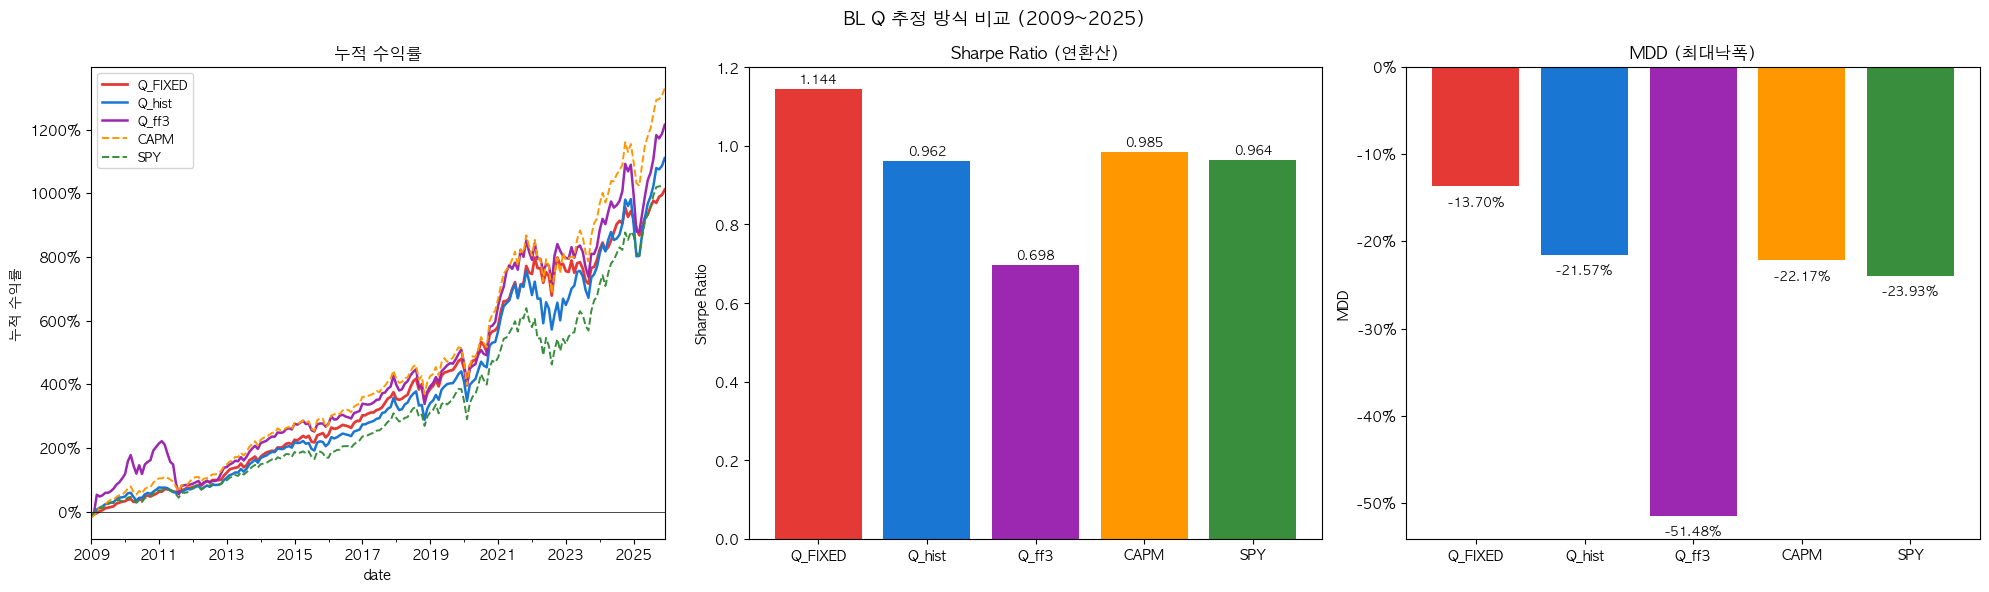

저장 완료


In [ ]:
# ── 시각화 ───────────────────────────────────────────────────
palette = {
    'Q_FIXED': ('#E53935', 2.0, '-'),
    'Q_hist':  ('#1976D2', 1.8, '-'),
    'Q_ff3':   ('#9C27B0', 1.8, '-'),
    'CAPM':    ('#FF9800', 1.4, '--'),
    'SPY':     ('#388E3C', 1.4, '--'),
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('BL Q 추정 방식 비교 (2009~2025)', fontsize=13, fontweight='bold')

# ① 누적 수익률
ax = axes[0]
for name, (color, lw, ls) in palette.items():
    cum = (1 + ret_series[name]).cumprod() - 1
    cum.plot(ax=ax, label=name, color=color, linewidth=lw, linestyle=ls)
ax.set_title('누적 수익률')
ax.set_ylabel('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)

# ② Sharpe Ratio
ax = axes[1]
names   = [s['label']  for s in stats]
sharpes = [s['sharpe'] for s in stats]
colors  = [palette[n][0] for n in names]
bars = ax.bar(names, sharpes, color=colors)
ax.set_title('Sharpe Ratio (연환산)')
ax.set_ylabel('Sharpe Ratio')
ax.axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ③ MDD
ax = axes[2]
mdds = [s['mdd'] for s in stats]
bars = ax.bar(names, mdds, color=colors)
ax.set_title('MDD (최대낙폭)')
ax.set_ylabel('MDD')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, mdds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.01,
            f'{val:.2%}', ha='center', va='top', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / 'q_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 결과 저장
result_df = pd.DataFrame(ret_series)
result_df.to_csv(DATA_DIR / 'q_comparison_returns.csv')
print('저장 완료')